# Region Risk CatBoost

Этот ноутбук разбит на отдельные логические шаги:

1. Подготовка окружения.
2. Загрузка и очистка исходных таблиц из `data/`.
3. Вспомогательные функции.
4. Кластерный анализ данных.
5. Построение регионально-часового датасета.
6. Обучение CatBoost-модели риска.
7. Проверка результата обучения.
8. Сохранение весов и `metadata.json` для бэкенда.

Финальная ячейка сохраняет артефакты в `models/catboost_region_risk/`. Именно эти файлы потом используются backend-сервисом для инференса.

## 1. Setup

Установите зависимости при первом запуске. Локально эту ячейку можно пропустить, если окружение уже собрано.

In [1]:
%pip install -q catboost openpyxl scikit-learn optuna

Note: you may need to restart the kernel to use updated packages.


## 2. Импорты и загрузка исходных данных

В этом блоке:

- определяются пути к репозиторию и каталогу `data/`,
- подключаются библиотеки,
- объявляются константы и функции чтения Excel/CSV,
- данные приводятся к единому формату `df`, который дальше используется в анализе и обучении.

По умолчанию ноутбук берёт:

- `data/incidents_2000.xlsx`
- `data/thrlist .xlsx`

При необходимости пути можно поменять в переменных `INCIDENTS_PATH` и `THREATLIST_PATH`.

In [2]:
import io
import re
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, silhouette_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.ml.region_risk.artifacts import save_catboost_artifacts

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data"
INCIDENTS_PATH = DATA_DIR / "incidents_2000.xlsx"
THREATLIST_PATH = DATA_DIR / "thrlist .xlsx"
ARTIFACT_DIR = PROJECT_ROOT / "models" / "catboost_region_risk"

INCIDENTS_COLUMNS = [
    'Тип предприятия',
    'Код предприятия',
    'Количество хостов',
    'Код реализованной угрозы',
    'Успех',
    'Регион размещения предприятия',
    'Дата инцидента',
    'Региональное время'
]
INCIDENTS_REQUIRED = set(INCIDENTS_COLUMNS)

THREAT_REQUIRED = {
    'Идентификатор УБИ',
    'Наименование УБИ',
    'Источник угрозы (характеристика и потенциал нарушителя)',
    'Объект воздействия',
    'Нарушение конфиденциальности',
    'Нарушение целостности',
    'Нарушение доступности'
}


def normalize_columns(df):
    df = df.copy()
    df.columns = [re.sub(r'\s+', ' ', str(c).strip()) for c in df.columns]
    return df


def read_table(file_name, file_bytes, no_header=False, manual_columns=None):
    lower_name = file_name.lower()
    if lower_name.endswith((".xlsx", ".xls")):
        df = pd.read_excel(io.BytesIO(file_bytes), header=None if no_header else 0)
        if no_header and manual_columns is not None:
            if df.shape[1] != len(manual_columns):
                raise ValueError(f"{file_name}: ожидалось {len(manual_columns)} колонок, получено {df.shape[1]}")
            df.columns = manual_columns
        return df

    encodings = ['utf-8', 'utf-8-sig', 'cp1251', 'latin1']
    seps = [None, ';', ',', '\t']
    last_error = None
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(
                    io.BytesIO(file_bytes),
                    encoding=enc,
                    sep=sep,
                    engine='python' if sep is None else 'c',
                    header=None if no_header else 0,
                )
                if no_header and manual_columns is not None:
                    if df.shape[1] != len(manual_columns):
                        continue
                    df.columns = manual_columns
                if df.shape[1] > 1:
                    return df
            except Exception as e:
                last_error = e
                continue
    raise ValueError(f"Не удалось прочитать {file_name}. Последняя ошибка: {last_error}")


def load_local_tables(incidents_path=INCIDENTS_PATH, threatlist_path=THREATLIST_PATH):
    tables = {}
    with open(incidents_path, 'rb') as f:
        incidents_bytes = f.read()
    with open(threatlist_path, 'rb') as f:
        threatlist_bytes = f.read()

    tables[incidents_path.name] = normalize_columns(
        read_table(incidents_path.name, incidents_bytes, no_header=False)
    )
    tables[threatlist_path.name] = normalize_columns(
        read_table(threatlist_path.name, threatlist_bytes, no_header=True)
    )
    return tables


def prepare_data():
    if IN_COLAB:
        print('📥 ЗАГРУЗИТЕ 2 ФАЙЛА: incidents и thrlist')
        uploaded = files.upload()
        tables = {}
        for name, content in uploaded.items():
            if 'incident' in name.lower():
                df = read_table(name, content, no_header=False)
            else:
                df = read_table(name, content, no_header=True)
            tables[name] = normalize_columns(df)
    else:
        tables = load_local_tables()

    incidents_name = next((name for name, df_ in tables.items() if INCIDENTS_REQUIRED.issubset(set(df_.columns))), None)
    threatlist_name = None
    for name, df_ in tables.items():
        if incidents_name == name:
            continue
        normalized_rows = []
        for idx in range(min(3, len(df_))):
            normalized_rows.append({re.sub(r'\s+', ' ', str(v).strip()) for v in df_.iloc[idx].tolist()})
        if any(THREAT_REQUIRED.issubset(row) for row in normalized_rows):
            threatlist_name = name
            break

    if incidents_name is None or threatlist_name is None:
        raise ValueError('Не удалось автоматически определить incidents и thrlist')

    incidents = tables[incidents_name].copy()
    threat_raw = tables[threatlist_name].copy()

    header_idx = 0
    for idx in range(min(5, len(threat_raw))):
        candidate = [re.sub(r'\s+', ' ', str(v).strip()) for v in threat_raw.iloc[idx].tolist()]
        if THREAT_REQUIRED.issubset(set(candidate)):
            header_idx = idx
            break
    threatlist = threat_raw.iloc[header_idx + 1 :].copy()
    threatlist.columns = [re.sub(r'\s+', ' ', str(v).strip()) for v in threat_raw.iloc[header_idx].tolist()]
    threatlist = threatlist.reset_index(drop=True)

    incidents = incidents.rename(columns={
        'Тип предприятия': 'org_type',
        'Код предприятия': 'enterprise_code',
        'Количество хостов': 'host_count',
        'Код реализованной угрозы': 'threat_code',
        'Успех': 'success',
        'Регион размещения предприятия': 'region',
        'Дата инцидента': 'incident_date',
        'Региональное время': 'regional_time'
    })
    threatlist = threatlist.rename(columns={
        'Идентификатор УБИ': 'threat_code',
        'Наименование УБИ': 'threat_name',
        'Источник угрозы (характеристика и потенциал нарушителя)': 'threat_source',
        'Объект воздействия': 'impact_object',
        'Нарушение конфиденциальности': 'confidentiality_violation',
        'Нарушение целостности': 'integrity_violation',
        'Нарушение доступности': 'availability_violation'
    })

    for col in ['org_type', 'region']:
        incidents[col] = incidents[col].astype(str).str.strip()
    incidents['enterprise_code'] = incidents['enterprise_code'].astype(str).str.strip()
    for col in ['host_count', 'threat_code', 'success']:
        incidents[col] = pd.to_numeric(incidents[col], errors='coerce')
    incidents['regional_time'] = pd.to_datetime(incidents['regional_time'], format='%d.%m.%Y %H:%M', errors='coerce')
    incidents['incident_date'] = pd.to_datetime(incidents['incident_date'], format='%d.%m.%Y', errors='coerce')
    incidents = incidents.dropna(subset=['org_type', 'enterprise_code', 'host_count', 'threat_code', 'success', 'region', 'regional_time']).copy()
    incidents['success'] = incidents['success'].astype(int)
    incidents = incidents[incidents['success'].isin([0, 1])].copy()

    for col in ['threat_name', 'threat_source', 'impact_object']:
        if col in threatlist.columns:
            threatlist[col] = threatlist[col].astype(str).str.strip()
    for col in ['threat_code', 'confidentiality_violation', 'integrity_violation', 'availability_violation']:
        if col in threatlist.columns:
            threatlist[col] = pd.to_numeric(threatlist[col], errors='coerce')
    threatlist = threatlist.dropna(subset=['threat_code']).drop_duplicates(subset=['threat_code'])

    df = incidents.merge(threatlist, on='threat_code', how='left')
    for col in ['threat_name', 'threat_source', 'impact_object']:
        if col in df.columns:
            df[col] = df[col].fillna('Неизвестно')
    for col in ['confidentiality_violation', 'integrity_violation', 'availability_violation']:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)

    df = df.sort_values('regional_time').reset_index(drop=True)
    print('✅ Данные подготовлены')
    print('shape =', df.shape)
    print('success=1:', f"{df['success'].mean():.2%}")
    print('period:', df['regional_time'].min(), '->', df['regional_time'].max())
    return df

print('PROJECT_ROOT =', PROJECT_ROOT)
print('INCIDENTS_PATH =', INCIDENTS_PATH)
print('THREATLIST_PATH =', THREATLIST_PATH)
print('ARTIFACT_DIR =', ARTIFACT_DIR)

PROJECT_ROOT = /home/main/PycharmProjects/hackathon-mipt-2026
INCIDENTS_PATH = /home/main/PycharmProjects/hackathon-mipt-2026/data/incidents_2000.xlsx
THREATLIST_PATH = /home/main/PycharmProjects/hackathon-mipt-2026/data/thrlist .xlsx
ARTIFACT_DIR = /home/main/PycharmProjects/hackathon-mipt-2026/models/catboost_region_risk


## 3. Вспомогательные функции

Эти функции используются дальше при feature engineering, подборе порога, генерации прогноза и описательных отчётах.

In [3]:
def safe_mode(series, default='Неизвестно'):
    s = series.dropna()
    if s.empty:
        return default
    mode = s.mode()
    return mode.iloc[0] if not mode.empty else default


def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    if month in [3, 4, 5]:
        return 'spring'
    if month in [6, 7, 8]:
        return 'summer'
    return 'autumn'


def get_day_period(hour):
    if 6 <= hour <= 11:
        return 'morning'
    if 12 <= hour <= 17:
        return 'day'
    if 18 <= hour <= 23:
        return 'evening'
    return 'night'


def top_label_from_proba(class_names, proba_row, top_k=3):
    pairs = list(zip(class_names, proba_row))
    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
    return pairs[:top_k]


def find_best_threshold_f1(y_true, y_proba):
    best_thr = 0.5
    best_f1 = -1
    for thr in np.arange(0.30, 0.81, 0.02):
        pred = (y_proba >= thr).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = thr
    return float(best_thr), float(best_f1)

## 4. Кластерный анализ

Этот блок нужен для исследовательского анализа: он показывает структуру данных, типичные кластеры инцидентов и их отличия по регионам, угрозам и объектам воздействия.

Для обучения модели этот шаг не обязателен, но полезен для sanity-check перед feature engineering.

In [4]:
def analyze_clusters_detailed(df, n_clusters=8):
    print('\n🔍 ПОДРОБНЫЙ АНАЛИЗ КЛАСТЕРОВ')
    print('=' * 50)

    numeric_features = [
        'host_count', 'threat_code', 'success',
        'confidentiality_violation', 'integrity_violation', 'availability_violation'
    ]
    numeric_features = [col for col in numeric_features if col in df.columns]
    if len(numeric_features) < 2:
        print('⚠️ Недостаточно числовых признаков для кластеризации')
        return None

    X = df[numeric_features].copy()
    X = X.fillna(X.median())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print('📊 Определение оптимального количества кластеров...')
    inertias = []
    silhouette_scores = []
    K_range = range(2, min(11, max(3, len(X_scaled) // 10)))
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        if len(np.unique(kmeans.labels_)) > 1:
            silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
        else:
            silhouette_scores.append(0)

    print(f'🎯 Выполняем кластеризацию с {n_clusters} кластерами...')
    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    df_clustered = df.copy()
    df_clustered['cluster'] = kmeans_labels
    cluster_analysis = []

    print(f'\n📋 ХАРАКТЕРИСТИКИ КЛАСТЕРОВ ({n_clusters} шт.):')
    print('=' * 80)
    for cluster_id in range(n_clusters):
        cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
        cluster_size = len(cluster_data)
        cluster_pct = cluster_size / len(df_clustered) * 100
        cluster_stats = {
            feature: {
                'mean': cluster_data[feature].mean(),
                'median': cluster_data[feature].median(),
                'std': cluster_data[feature].std(),
            }
            for feature in numeric_features
        }
        categorical_features = ['org_type', 'region', 'threat_name', 'impact_object']
        categorical_stats = {}
        for feature in categorical_features:
            if feature in cluster_data.columns:
                categorical_stats[feature] = cluster_data[feature].value_counts().head(3).to_dict()

        cluster_info = {
            'cluster_id': cluster_id,
            'size': cluster_size,
            'percentage': cluster_pct,
            'numeric_stats': cluster_stats,
            'categorical_stats': categorical_stats,
            'success_rate': cluster_data['success'].mean(),
        }
        cluster_analysis.append(cluster_info)

        print(f'\n📊 КЛАСТЕР {cluster_id} (размер: {cluster_size} ({cluster_pct:.1f}%))')
        print(f"   Уровень угрозы: {cluster_data['success'].mean():.1%}")
        if 'threat_name' in categorical_stats:
            print(f"   Топ угроз: {', '.join(list(categorical_stats['threat_name'].keys())[:3])}")
        if 'region' in categorical_stats:
            print(f"   Топ регионов: {', '.join(list(categorical_stats['region'].keys())[:3])}")
        if 'impact_object' in categorical_stats:
            print(f"   Топ объектов: {', '.join(list(categorical_stats['impact_object'].keys())[:3])}")
        print(f"   Среднее количество хостов: {cluster_stats['host_count']['mean']:.0f}")
        danger_level = '🔴 ВЫСОКИЙ' if cluster_data['success'].mean() > 0.6 else '🟡 СРЕДНИЙ' if cluster_data['success'].mean() > 0.4 else '🟢 НИЗКИЙ'
        print(f'   Уровень опасности: {danger_level}')

    try:
        pca = PCA(n_components=min(2, len(numeric_features)))
        X_pca = pca.fit_transform(X_scaled)
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6)
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)")
        plt.title('Визуализация кластеров (PCA)')
        plt.colorbar(scatter)
        plt.tight_layout()
        plt.show()
        print(f"\n📈 PCA объясняет {sum(pca.explained_variance_ratio_):.1%} общей дисперсии")
    except Exception:
        print('⚠️ Не удалось построить визуализацию кластеров')

    results = {
        'KMeans': {
            'labels': kmeans_labels,
            'silhouette': silhouette_score(X_scaled, kmeans_labels),
            'n_clusters': len(np.unique(kmeans_labels)),
        }
    }
    try:
        dbscan = DBSCAN(eps=0.5, min_samples=5)
        dbscan_labels = dbscan.fit_predict(X_scaled)
        n_dbscan_clusters = len(np.unique(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        if n_dbscan_clusters > 1:
            results['DBSCAN'] = {
                'labels': dbscan_labels,
                'silhouette': silhouette_score(X_scaled, dbscan_labels),
                'n_clusters': n_dbscan_clusters,
            }
        else:
            results['DBSCAN'] = None
    except Exception:
        results['DBSCAN'] = None

    return {
        'clustered_data': df_clustered,
        'cluster_analysis': cluster_analysis,
        'clustering_results': results,
        'features_used': numeric_features,
        'scaler': scaler,
    }


def print_cluster_analysis(cluster_results):
    if not cluster_results:
        return
    print('\n' + '=' * 80)
    print('🔍 ПОДРОБНЫЙ АНАЛИЗ КЛАСТЕРОВ')
    print('=' * 80)
    for cluster_info in cluster_results['cluster_analysis']:
        cluster_id = cluster_info['cluster_id']
        size = cluster_info['size']
        pct = cluster_info['percentage']
        success_rate = cluster_info['success_rate']
        print(f'\n📊 КЛАСТЕР {cluster_id}')
        print(f'   Размер: {size} записей ({pct:.1f}%)')
        print(f'   Уровень угрозы: {success_rate:.1%}')
        danger_level = '🔴 ВЫСОКИЙ' if success_rate > 0.6 else '🟡 СРЕДНИЙ' if success_rate > 0.4 else '🟢 НИЗКИЙ'
        print(f'   Уровень опасности: {danger_level}')
        categorical_stats = cluster_info['categorical_stats']
        if 'threat_name' in categorical_stats and categorical_stats['threat_name']:
            print('   Топ угроз:')
            for threat, count in list(categorical_stats['threat_name'].items())[:3]:
                print(f'     • {threat} ({count} случаев)')
        if 'region' in categorical_stats and categorical_stats['region']:
            print('   Топ регионов:')
            for region, count in list(categorical_stats['region'].items())[:3]:
                print(f'     • {region} ({count} случаев)')
        if 'impact_object' in categorical_stats and categorical_stats['impact_object']:
            print('   Топ объектов воздействия:')
            for obj, count in list(categorical_stats['impact_object'].items())[:3]:
                print(f'     • {obj} ({count} случаев)')
        numeric_stats = cluster_info['numeric_stats']
        if 'host_count' in numeric_stats:
            print(f"   Среднее количество хостов: {numeric_stats['host_count']['mean']:.0f}")
        if 'threat_code' in numeric_stats:
            print(f"   Средний код угрозы: {numeric_stats['threat_code']['mean']:.0f}")

    print('\n🔍 СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:')
    print('=' * 50)
    for method, result in cluster_results['clustering_results'].items():
        if result:
            print(f"   {method}: {result['n_clusters']} кластеров, Silhouette={result['silhouette']:.4f}")
        else:
            print(f'   {method}: не удалось выполнить')

## 5. Feature engineering и обучение модели

Ниже расположен основной production-блок:

- сбор `region_hour_df`,
- лаговые и rolling-признаки,
- временная валидация `TimeSeriesSplit`,
- подбор порога по F1,
- возврат лучшей модели и метрик.

Именно этот блок определяет, какие признаки потом ожидает backend при инференсе.

In [5]:
FEATURE_COLUMNS = [
    'incidents_count', 'unique_enterprises', 'unique_threats', 'avg_host_count', 'median_host_count',
    'avg_host_count_log', 'median_host_count_log', 'threat_danger_score', 'hour', 'dayofweek', 'month',
    'quarter', 'is_weekend', 'is_working_hours', 'is_peak_hours', 'lag_attack_1', 'lag_attack_2',
    'lag_attack_3', 'lag_attack_6', 'lag_attack_12', 'lag_attack_24', 'lag_incidents_1',
    'lag_incidents_2', 'lag_incidents_3', 'lag_incidents_6', 'lag_incidents_12', 'lag_incidents_24',
    'lag_success_1', 'lag_success_2', 'lag_success_3', 'lag_success_6', 'lag_success_12', 'lag_success_24',
    'rolling_attack_mean_6', 'rolling_attack_mean_24', 'rolling_incidents_sum_6', 'rolling_incidents_sum_24',
    'rolling_success_sum_6', 'rolling_success_sum_24', 'region', 'dominant_org_type',
    'dominant_threat_source', 'dominant_impact_object', 'season', 'day_period'
]
CAT_FEATURES = ['region', 'dominant_org_type', 'dominant_threat_source', 'dominant_impact_object', 'season', 'day_period']


def build_region_hour_dataset(df):
    print('\n🔧 ПОСТРОЕНИЕ РЕГИОНАЛЬНО-ЧАСОВОГО ДАТАСЕТА...')
    work = df.copy()
    work['time_hour'] = work['regional_time'].dt.floor('H')

    grouped = work.groupby(['region', 'time_hour']).agg(
        incidents_count=('success', 'size'),
        successful_count=('success', 'sum'),
        unique_enterprises=('enterprise_code', 'nunique'),
        unique_threats=('threat_code', 'nunique'),
        avg_host_count=('host_count', 'mean'),
        median_host_count=('host_count', 'median'),
        dominant_org_type=('org_type', lambda x: safe_mode(x, default='Неизвестно')),
        dominant_threat_source=('threat_source', lambda x: safe_mode(x, default='Неизвестно')),
        dominant_impact_object=('impact_object', lambda x: safe_mode(x, default='Неизвестно')),
    ).reset_index()

    if {'confidentiality_violation', 'integrity_violation', 'availability_violation'}.issubset(work.columns):
        threat_danger = work.groupby(['region', 'time_hour']).apply(
            lambda x: (
                x['confidentiality_violation'].fillna(0).astype(int)
                + x['integrity_violation'].fillna(0).astype(int)
                + x['availability_violation'].fillna(0).astype(int)
            ).max()
        ).reset_index(name='threat_danger_score')
    else:
        threat_danger = work.groupby(['region', 'time_hour'])['success'].max().reset_index(name='threat_danger_score')

    grouped = grouped.merge(threat_danger, on=['region', 'time_hour'], how='left')
    grouped['threat_danger_score'] = grouped['threat_danger_score'].fillna(0)
    grouped['attack_present'] = (grouped['successful_count'] > 0).astype(int)

    all_regions = grouped['region'].dropna().unique().tolist()
    min_time = grouped['time_hour'].min()
    max_time = grouped['time_hour'].max()
    full_time_index = pd.date_range(min_time, max_time, freq='H')
    full_grid = pd.MultiIndex.from_product([all_regions, full_time_index], names=['region', 'time_hour']).to_frame(index=False)
    full_df = full_grid.merge(grouped, on=['region', 'time_hour'], how='left')

    full_df['incidents_count'] = full_df['incidents_count'].fillna(0)
    full_df['successful_count'] = full_df['successful_count'].fillna(0)
    full_df['unique_enterprises'] = full_df['unique_enterprises'].fillna(0)
    full_df['unique_threats'] = full_df['unique_threats'].fillna(0)
    full_df['avg_host_count'] = full_df.groupby('region')['avg_host_count'].transform(lambda x: x.fillna(x.median()))
    full_df['median_host_count'] = full_df.groupby('region')['median_host_count'].transform(lambda x: x.fillna(x.median()))
    full_df['avg_host_count'] = full_df['avg_host_count'].fillna(full_df['avg_host_count'].median())
    full_df['median_host_count'] = full_df['median_host_count'].fillna(full_df['median_host_count'].median())

    for col in ['dominant_org_type', 'dominant_threat_source', 'dominant_impact_object']:
        full_df[col] = full_df.groupby('region')[col].transform(lambda x: x.fillna(safe_mode(x, default='Неизвестно')))
        full_df[col] = full_df[col].fillna('Неизвестно')

    full_df['threat_danger_score'] = full_df['threat_danger_score'].fillna(0)
    full_df['attack_present'] = full_df['attack_present'].fillna(0).astype(int)

    full_df['hour'] = full_df['time_hour'].dt.hour
    full_df['dayofweek'] = full_df['time_hour'].dt.dayofweek
    full_df['month'] = full_df['time_hour'].dt.month
    full_df['quarter'] = full_df['time_hour'].dt.quarter
    full_df['is_weekend'] = (full_df['dayofweek'] >= 5).astype(int)
    full_df['is_working_hours'] = full_df['hour'].between(9, 18).astype(int)
    full_df['is_peak_hours'] = full_df['hour'].isin([10, 11, 14, 15, 16, 17]).astype(int)
    full_df['season'] = full_df['month'].apply(get_season)
    full_df['day_period'] = full_df['hour'].apply(get_day_period)

    full_df = full_df.sort_values(['region', 'time_hour']).reset_index(drop=True)
    for lag in [1, 2, 3, 6, 12, 24]:
        full_df[f'lag_attack_{lag}'] = full_df.groupby('region')['attack_present'].shift(lag).fillna(0)
        full_df[f'lag_incidents_{lag}'] = full_df.groupby('region')['incidents_count'].shift(lag).fillna(0)
        full_df[f'lag_success_{lag}'] = full_df.groupby('region')['successful_count'].shift(lag).fillna(0)

    full_df['rolling_attack_mean_6'] = (
        full_df.groupby('region')['attack_present'].shift(1).rolling(6, min_periods=1).mean().fillna(0)
    )
    full_df['rolling_attack_mean_24'] = (
        full_df.groupby('region')['attack_present'].shift(1).rolling(24, min_periods=1).mean().fillna(0)
    )
    full_df['rolling_incidents_sum_6'] = (
        full_df.groupby('region')['incidents_count'].shift(1).rolling(6, min_periods=1).sum().fillna(0)
    )
    full_df['rolling_incidents_sum_24'] = (
        full_df.groupby('region')['incidents_count'].shift(1).rolling(24, min_periods=1).sum().fillna(0)
    )
    full_df['rolling_success_sum_6'] = (
        full_df.groupby('region')['successful_count'].shift(1).rolling(6, min_periods=1).sum().fillna(0)
    )
    full_df['rolling_success_sum_24'] = (
        full_df.groupby('region')['successful_count'].shift(1).rolling(24, min_periods=1).sum().fillna(0)
    )
    full_df['avg_host_count_log'] = np.log1p(full_df['avg_host_count'])
    full_df['median_host_count_log'] = np.log1p(full_df['median_host_count'])

    print(f"✅ region_hour_df shape={full_df.shape}")
    print(f"✅ Доля часов с attack_present=1: {full_df['attack_present'].mean():.2%}")
    return full_df


def optimize_model_with_optuna(X_train, y_train, X_val, y_val, cat_features_indices):
    print('🔍 Подбор гиперпараметров...')
    try:
        import optuna
    except Exception:
        optuna = None

    if optuna is None:
        param_combinations = [
            {'iterations': 400, 'depth': 6, 'learning_rate': 0.07, 'l2_leaf_reg': 4, 'bagging_temperature': 0.3},
            {'iterations': 500, 'depth': 5, 'learning_rate': 0.08, 'l2_leaf_reg': 5, 'bagging_temperature': 0.5},
            {'iterations': 600, 'depth': 7, 'learning_rate': 0.06, 'l2_leaf_reg': 3, 'bagging_temperature': 0.7},
            {'iterations': 450, 'depth': 6, 'learning_rate': 0.09, 'l2_leaf_reg': 6, 'bagging_temperature': 0.4},
        ]
        best_f1 = 0
        best_params = None
        for params in param_combinations:
            model_params = {
                **params,
                'loss_function': 'Logloss',
                'eval_metric': 'F1',
                'auto_class_weights': 'Balanced',
                'random_seed': RANDOM_STATE,
                'verbose': 0,
                'random_strength': 0.8,
            }
            model = CatBoostClassifier(**model_params)
            train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
            val_pool = Pool(X_val, y_val, cat_features=cat_features_indices)
            model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=30, use_best_model=True, verbose=0)
            val_proba = model.predict_proba(X_val)[:, 1]
            _, current_f1 = find_best_threshold_f1(y_val, val_proba)
            if current_f1 > best_f1:
                best_f1 = current_f1
                best_params = model_params
        return best_params

    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 200, 800),
            'depth': trial.suggest_int('depth', 4, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_strength': trial.suggest_float('random_strength', 0.1, 1.0),
            'loss_function': 'Logloss',
            'eval_metric': 'F1',
            'auto_class_weights': 'Balanced',
            'random_seed': RANDOM_STATE,
            'verbose': 0,
        }
        model = CatBoostClassifier(**params)
        train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
        val_pool = Pool(X_val, y_val, cat_features=cat_features_indices)
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=30, use_best_model=True, verbose=0)
        val_proba = model.predict_proba(X_val)[:, 1]
        _, best_f1 = find_best_threshold_f1(y_val, val_proba)
        return best_f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)
    return {
        **study.best_params,
        'loss_function': 'Logloss',
        'eval_metric': 'F1',
        'auto_class_weights': 'Balanced',
        'random_seed': RANDOM_STATE,
        'verbose': 0,
    }


def train_region_risk_model(region_hour_df, use_optuna=False, max_train_rows=None):
    print('\n' + '=' * 60)
    print('1️⃣ ОБУЧЕНИЕ РЕГИОНАЛЬНОЙ МОДЕЛИ РИСКА')
    print('=' * 60)

    working_df = region_hour_df.sort_values(['region', 'time_hour']).reset_index(drop=True)
    if max_train_rows is not None and len(working_df) > max_train_rows:
        working_df = working_df.tail(max_train_rows).copy()
        print(f'Используем последние {max_train_rows:,} строк для обучения.')

    feature_cols = [c for c in FEATURE_COLUMNS if c in working_df.columns]
    cat_features = [c for c in CAT_FEATURES if c in feature_cols]

    X_all = working_df[feature_cols]
    y_all = working_df['attack_present']
    tscv = TimeSeriesSplit(n_splits=3)

    fold_results = []
    models = []
    thresholds = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all), 1):
        X_train = X_all.iloc[train_idx].copy()
        y_train = y_all.iloc[train_idx].copy()
        X_val = X_all.iloc[val_idx].copy()
        y_val = y_all.iloc[val_idx].copy()

        cat_idx = [feature_cols.index(c) for c in cat_features if c in feature_cols]
        train_pool = Pool(X_train, y_train, cat_features=cat_idx)
        val_pool = Pool(X_val, y_val, cat_features=cat_idx)

        if use_optuna and fold <= 2 and len(y_train) > 100:
            best_params = optimize_model_with_optuna(X_train, y_train, X_val, y_val, cat_idx)
            model = CatBoostClassifier(**best_params)
        else:
            model = CatBoostClassifier(
                iterations=700,
                depth=6,
                learning_rate=0.08,
                l2_leaf_reg=5,
                bagging_temperature=0.5,
                random_strength=0.8,
                loss_function='Logloss',
                eval_metric='F1',
                auto_class_weights='Balanced',
                random_seed=RANDOM_STATE + fold,
                verbose=0,
            )

        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50, use_best_model=True)
        val_proba = model.predict_proba(X_val)[:, 1]
        best_thr, best_f1 = find_best_threshold_f1(y_val, val_proba)
        fold_results.append({
            'fold': fold,
            'f1': best_f1,
            'threshold': best_thr,
            'precision': precision_score(y_val, (val_proba >= best_thr).astype(int), zero_division=0),
            'recall': recall_score(y_val, (val_proba >= best_thr).astype(int), zero_division=0),
            'auc': roc_auc_score(y_val, val_proba),
        })
        models.append((model, feature_cols, cat_features))
        thresholds.append(best_thr)
        print(f"Fold {fold}: F1={best_f1:.4f}, threshold={best_thr:.2f}, AUC={roc_auc_score(y_val, val_proba):.4f}")

    cv_df = pd.DataFrame(fold_results)
    print('\n📊 Средние метрики по временной CV:')
    print(f"   F1: {cv_df['f1'].mean():.4f} (+/- {cv_df['f1'].std():.4f})")
    print(f"   Precision: {cv_df['precision'].mean():.4f}")
    print(f"   Recall: {cv_df['recall'].mean():.4f}")
    print(f"   AUC: {cv_df['auc'].mean():.4f}")

    best_idx = int(cv_df['f1'].idxmax())
    best_model, best_features, best_cat_features = models[best_idx]
    best_threshold = thresholds[best_idx]
    return {
        'model': best_model,
        'features': best_features,
        'cat_features': best_cat_features,
        'threshold': best_threshold,
        'cv_results': cv_df,
        'region_hour_df': working_df,
    }

## 6. Запуск пайплайна обучения

Здесь выполняется практическая часть:

- загрузка и подготовка `df`,
- при желании — кластерный анализ,
- построение `region_hour_df`,
- обучение модели,
- вывод метрик.

После успешного выполнения в памяти должны появиться `risk_artifacts`, `model`, `feature_cols`, `cat_feature_names`, `threshold`.

✅ Данные подготовлены
shape = (2000, 19)
success=1: 50.25%
period: 2023-01-01 05:50:00 -> 2026-01-01 02:34:00

🔍 ПОДРОБНЫЙ АНАЛИЗ КЛАСТЕРОВ
📊 Определение оптимального количества кластеров...


🎯 Выполняем кластеризацию с 8 кластерами...

📋 ХАРАКТЕРИСТИКИ КЛАСТЕРОВ (8 шт.):

📊 КЛАСТЕР 0 (размер: 253 (12.7%))
   Уровень угрозы: 100.0%
   Топ угроз: Угроза несанкционированного доступа к активному и (или) пассивному виртуальному и (или) физическому сетевому оборудованию из физической и (или) виртуальной сети, Угроза межсайтового скриптинга, Угроза невозможности управления правами пользователей BIOS
   Топ регионов: Республика Татарстан, Алтайский край, Республика Саха (Якутия)
   Топ объектов: Микропрограммное обеспечение BIOS/UEFI, Системное программное обеспечение, прикладное программное обеспечение, сетевое программное обеспечение, Сетевой узел, сетевое программное обеспечение
   Среднее количество хостов: 1520
   Уровень опасности: 🔴 ВЫСОКИЙ

📊 КЛАСТЕР 1 (размер: 197 (9.8%))
   Уровень угрозы: 100.0%
   Топ угроз: Угроза неправомерного ознакомления с защищаемой информацией, Угроза подмены доверенного пользователя, Угроза доступа к локальным файлам сервера при помощи URL
   Т

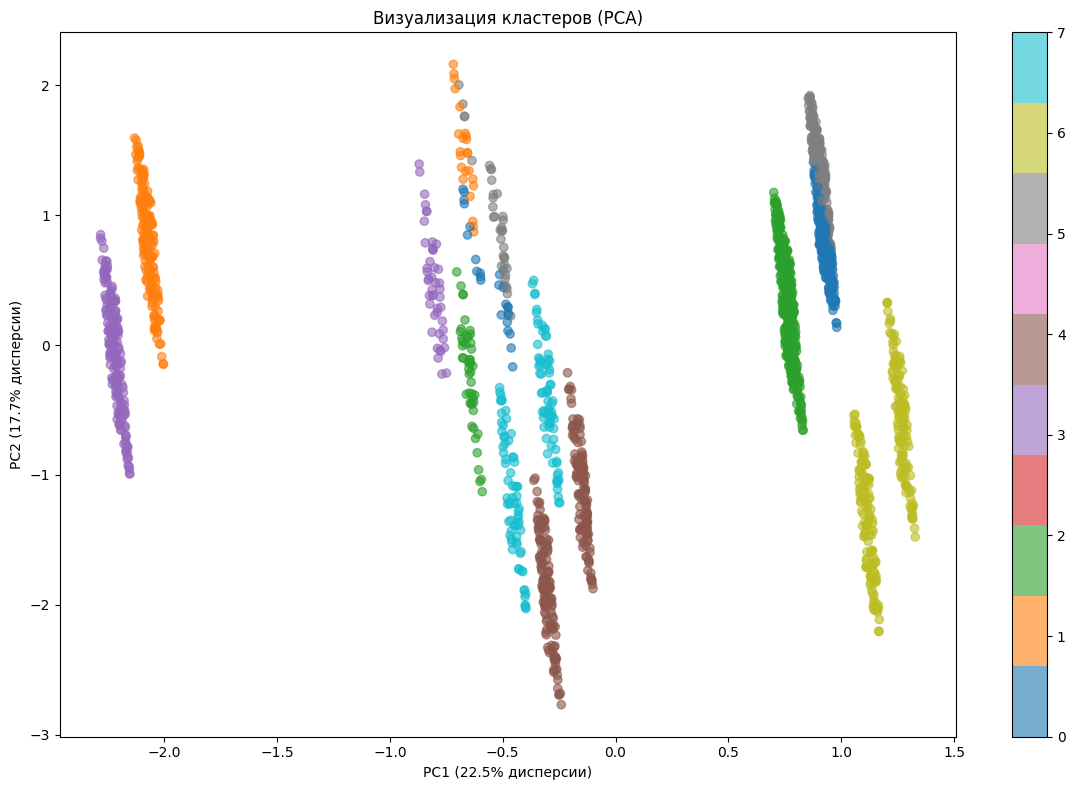


📈 PCA объясняет 40.2% общей дисперсии

🔍 ПОДРОБНЫЙ АНАЛИЗ КЛАСТЕРОВ

📊 КЛАСТЕР 0
   Размер: 253 записей (12.7%)
   Уровень угрозы: 100.0%
   Уровень опасности: 🔴 ВЫСОКИЙ
   Топ угроз:
     • Угроза несанкционированного доступа к активному и (или) пассивному виртуальному и (или) физическому сетевому оборудованию из физической и (или) виртуальной сети (8 случаев)
     • Угроза межсайтового скриптинга (7 случаев)
     • Угроза невозможности управления правами пользователей BIOS (6 случаев)
   Топ регионов:
     • Республика Татарстан (7 случаев)
     • Алтайский край (7 случаев)
     • Республика Саха (Якутия) (6 случаев)
   Топ объектов воздействия:
     • Микропрограммное обеспечение BIOS/UEFI (22 случаев)
     • Системное программное обеспечение, прикладное программное обеспечение, сетевое программное обеспечение (15 случаев)
     • Сетевой узел, сетевое программное обеспечение (15 случаев)
   Среднее количество хостов: 1520
   Средний код угрозы: 105

📊 КЛАСТЕР 1
   Размер: 197 запис

✅ region_hour_df shape=(2314576, 48)
✅ Доля часов с attack_present=1: 0.04%

1️⃣ ОБУЧЕНИЕ РЕГИОНАЛЬНОЙ МОДЕЛИ РИСКА


[I 2026-04-18 16:01:02,807] A new study created in memory with name: no-name-6229ce05-e7b1-4be8-8640-7b960cdee888


Используем последние 50,000 строк для обучения.
🔍 Подбор гиперпараметров...


[I 2026-04-18 16:01:03,200] Trial 0 finished with value: 0.6666666666666666 and parameters: {'iterations': 598, 'depth': 7, 'learning_rate': 0.16377753950831322, 'l2_leaf_reg': 9.217926078107904, 'bagging_temperature': 0.9397893554450859, 'random_strength': 0.3279448435264443}. Best is trial 0 with value: 0.6666666666666666.


...

[I 2026-04-18 16:01:18,029] Trial 18 finished with value: 0.625 and parameters: {'iterations': 291, 'depth': 7, 'learning_rate': 0.15116000217553127, 'l2_leaf_reg': 2.5996916899225773, 'bagging_temperature': 0.7536220241330287, 'random_strength': 0.7677621731834801}. Best is trial 18 with value: 0.625.


[I 2026-04-18 16:01:18,540] Trial 19 finished with value: 0.5882352941176471 and parameters: {'iterations': 226, 'depth': 8, 'learning_rate': 0.14690272901521337, 'l2_leaf_reg': 2.180178383938035, 'bagging_temperature': 0.7996895096296855, 'random_strength': 0.7755482152938004}. Best is trial 18 with value: 0.625.


Fold 2: F1=0.6250, threshold=0.70, AUC=0.9996


Fold 3: F1=0.7143, threshold=0.64, AUC=0.9999

📊 Средние метрики по временной CV:
   F1: 0.6687 (+/- 0.0447)
   Precision: 0.5265
   Recall: 0.9444
   AUC: 0.9997


,fold,f1,threshold,precision,recall,auc
0,1,0.666667,0.50,0.500000,1.000000,0.999707
1,2,0.625000,0.70,0.454545,1.000000,0.999600
2,3,0.714286,0.64,0.625000,0.833333,0.999860


In [6]:
df = prepare_data()
cluster_results = analyze_clusters_detailed(df, n_clusters=8)
print_cluster_analysis(cluster_results)

region_hour_df = build_region_hour_dataset(df)
risk_artifacts = train_region_risk_model(region_hour_df, use_optuna=True, max_train_rows=50_000)

model = risk_artifacts['model']
feature_cols = risk_artifacts['features']
cat_feature_names = risk_artifacts['cat_features']
threshold = risk_artifacts['threshold']

risk_artifacts['cv_results']

## 7. Проверка перед сохранением

Эта ячейка помогает быстро убедиться, что модель обучилась и все нужные переменные готовы для сериализации.

Она ничего не пишет на диск.

In [7]:
summary = {
    'train_rows': len(risk_artifacts['region_hour_df']),
    'feature_count': len(feature_cols),
    'cat_features': cat_feature_names,
    'threshold': float(threshold),
    'cv_mean_f1': float(risk_artifacts['cv_results']['f1'].mean()),
}
summary

{'train_rows': 50000,
 'feature_count': 45,
 'cat_features': ['region',
  'dominant_org_type',
  'dominant_threat_source',
  'dominant_impact_object',
  'season',
  'day_period'],
 'threshold': 0.6400000000000003,
 'cv_mean_f1': 0.6686507936507936}

## 8. Сохранение весов для backend-инференса

**Это финальная ячейка ноутбука.**

Она сохраняет именно те артефакты, которые затем читает backend:

- `models/catboost_region_risk/region_risk.cbm`
- `models/catboost_region_risk/metadata.json`

После запуска этой ячейки можно переходить к проверке API: сервис должен использовать именно эти веса для ML-предсказания.

In [8]:
artifact_dir = save_catboost_artifacts(
    model,
    feature_cols,
    cat_feature_names,
    threshold,
    output_dir=ARTIFACT_DIR,
)

print('Артефакты сохранены в:', artifact_dir.resolve())

Артефакты сохранены в: /home/main/PycharmProjects/hackathon-mipt-2026/models/catboost_region_risk
